In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import datetime
current_year = datetime.datetime.now().year
sns.set()

In [2]:
# loading the data from csv file to pandas dataframe and print first 10 lines
df = pd.read_csv("car_data.csv")
print(f"size of this datbase is {len(df)} ")
df.head(10)

size of this datbase is 301 


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [3]:
# checking number of messing value in our database
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [4]:
# number of category we have in this 2 columns
print(df.Fuel_Type.value_counts())
print(df.Seller_Type.value_counts())
print(df.Transmission.value_counts())
print(df.Owner.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64
Owner
0    290
1     10
3      1
Name: count, dtype: int64


In [5]:
# normalize data using one hot enconding
df = pd.get_dummies(
    df,
    columns=['Fuel_Type'],
    drop_first=True,
    dtype=int
)
# encoding our data 
df['Transmission'] = df['Transmission'].map({'Manual':0, 'Automatic' : 1})
df['Seller_Type'] = df['Seller_Type'].map({'Individual' : 0,'Dealer' : 1})
# scaling our data 
scaler = MinMaxScaler()
df[['Kms_Driven']] = scaler.fit_transform(df[['Kms_Driven']])
df[['Present_Price']] = scaler.fit_transform(df[['Present_Price']])
# car_age = current year - production year
df[['Year']] = current_year - df[['Year']]
df.rename(columns={'Year': 'car_age'}, inplace=True)
df[['car_age']] = scaler.fit_transform(df[['car_age']])
# save car name column and drop it from dat frame
df.head(21)

,Car_Name,car_age,Selling_Price,Present_Price,Kms_Driven,Seller_Type,Transmission,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol
0,ritz,0.266667,3.35,0.057109,0.053053,1,0,0,0,1
1,sx4,0.333333,4.75,0.099913,0.085085,1,0,0,1,0
2,ciaz,0.066667,7.25,0.103273,0.012813,1,0,0,0,1
3,wagon r,0.466667,2.85,0.041504,0.009409,1,0,0,0,1
4,swift,0.266667,4.60,0.070980,0.083984,1,0,0,1,0
5,vitara brezza,0.000000,9.25,0.103056,0.003145,1,0,0,1,0
6,ciaz,0.200000,6.75,0.084525,0.036629,1,0,0,0,1
7,s cross,0.200000,6.50,0.089835,0.065924,1,0,0,1,0
8,ciaz,0.133333,8.75,0.092870,0.039586,1,0,0,1,0
9,ciaz,0.200000,7.45,0.093195,0.083818,1,0,0,1,0


In [6]:
# defined features we use it to do preduction to car price and defined Y result
#split our data, 80% of data for trianing and 20% data for testing
X = df.drop(['Selling_Price', 'Car_Name'] , axis=1)
Y = df['Selling_Price' ]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)
print(y_pred)

[ 2.95534303  8.178939    6.45427257 -1.42417501  9.08889914  7.41825441
  1.33644285  0.84027217  1.36501949  7.49026806  9.11830017  0.58573931
  8.41612774  3.42316502  6.90043281  3.04988309  0.48448171 10.70970753
  1.75207005  2.34571752  0.39746889  8.11925338  6.62469317  2.65939066
  0.78280554  3.69330765  5.24815462  2.82676351  2.13640446  1.75237686
  0.39730155  9.11750503 -0.66188053  2.29098014  8.57067341  4.4910324
  7.20530369  7.53824015  2.89101139  7.93588794  3.93585154  4.27133211
  4.33205704  0.6008847   7.34025071  0.47602539  7.29187681 11.23125597
  3.13805132  5.38262985  6.7988422   2.17888955 20.63303305 17.0015261
  7.50717349  9.69621308  4.47478116  8.97377615  1.82294639  7.60416734
  0.22226536]


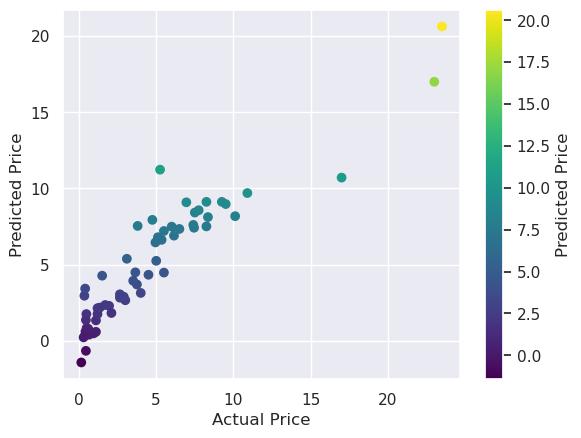

In [28]:
scatter = plt.scatter(Y_test,y_pred,c=y_pred,cmap='viridis')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.colorbar(scatter, label="Predicted Price")
plt.show()
